<a href="https://colab.research.google.com/github/vivaanjain20-ctrl/CodingClubMLRecruitmentTask/blob/main/CC_ML_Task_Cleaning_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Currency Cleaning**



In [122]:
df_curr = pd.read_csv("/content/tour_logs_train.csv")
df_curr['Ticket_Price'] = df_curr['Ticket_Price'].str.replace('Free', '0')
df_curr['Currency'] = '$'
df_curr['Currency'] = df_curr['Ticket_Price'].str.extract(r'([$£€A-Z]+)')
df_curr['Currency'] = df_curr['Currency'].fillna('$')
df_curr['Currency'] = df_curr['Currency'].str.replace('USD','$')
df_curr['Ticket_Price'] = df_curr['Ticket_Price'].str.split(' ').str[0]
df_curr['Ticket_Price'] = df_curr['Ticket_Price'].str.replace(r'[^\d.]', '', regex=True)
df_curr['Ticket_Price'] = df_curr['Ticket_Price'].astype(float)
rates = {
    '£': 1.27,
    '€': 1.09,
    '$': 1.0
}
df_curr['Rate'] = df_curr['Currency'].map(rates).fillna(1.0)
df_curr['Ticket_Price'] = df_curr['Ticket_Price'] * df_curr['Rate']
df_curr = df_curr.drop(columns=['Rate'])
df_curr = df_curr.drop(columns=['Currency'])

# **Date Cleaning**

In [123]:
df_date= df_curr.copy()
df_date = df_date[df_date['Show_DateTime'].str.match(r'^\d', na=False)]
df_date['clean_datetime'] = pd.to_datetime(df_date['Show_DateTime'],format='mixed',dayfirst=True,errors='coerce')
df_date = df_date.dropna(subset=['clean_datetime'])
df_date['Date'] = df_date['clean_datetime'].dt.strftime('%Y-%m-%d')
df_date['Time'] = df_date['clean_datetime'].dt.strftime('%H:%M:%S')
df_date = df_date.drop(columns=['clean_datetime'])
df_date = df_date.drop(columns=['Show_DateTime'])

# **Cleaning Obviously Wrong Values**

In [124]:
df_clean = df_date.copy()
cols = ['Ticket_Price', 'Crowd_Energy', 'Crowd_Size', 'Volume_Level']
for col in cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean[
    (df_clean['Ticket_Price'] >= 0) &
    (df_clean['Ticket_Price'] <= 300)
]
df_clean = df_clean[
    (df_clean['Crowd_Size'] >= 0) &
    (df_clean['Crowd_Size'] <= 2000)
]

mask_invalid_energy = (df_clean['Crowd_Energy'] < 0) | (df_clean['Crowd_Energy'] > 100)
df_clean.loc[mask_invalid_energy, 'Crowd_Energy'] = np.nan

df_clean['Crowd_Energy'] = df_clean.groupby('Venue_ID')['Crowd_Energy'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['Volume_Level'] = df_clean.groupby('Venue_ID')['Volume_Level'].transform(
    lambda x: x.fillna(x.median())
)

# **Verifying Each Hypothesis from the scribbles manually**

**Verifying Tuesday Curse**

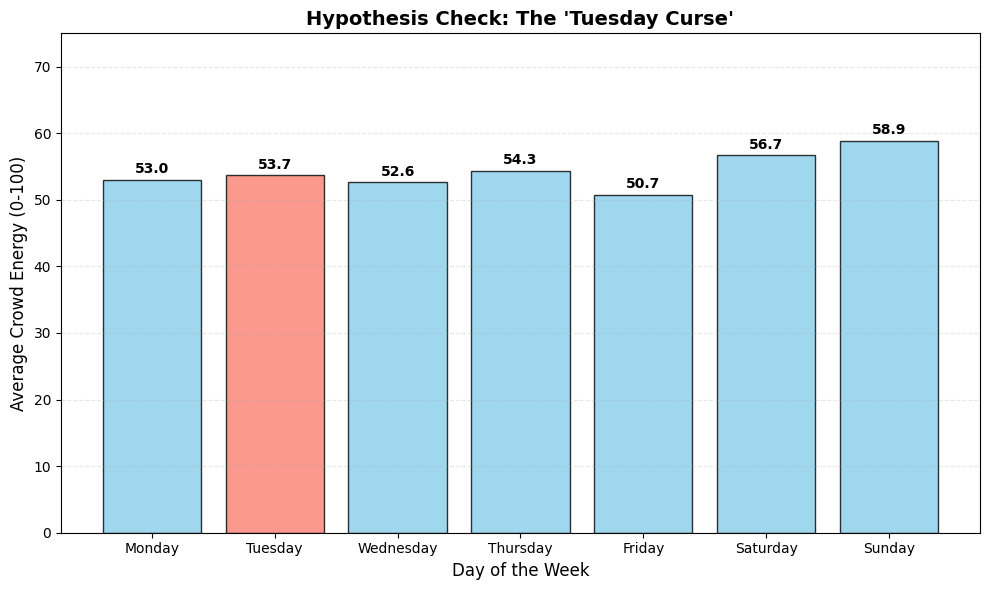

In [125]:
day_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

df_clean['Day_Name'] = df_clean['Day_of_Week'].map(day_mapping)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_energy = df_clean.groupby('Day_Name')['Crowd_Energy'].mean().reindex(days_order)

plt.figure(figsize=(10, 6))

colors = ['skyblue' if day != 'Tuesday' else 'salmon' for day in days_order]

plt.bar(daily_energy.index, daily_energy.values, color=colors, edgecolor='black', alpha=0.8)

plt.title("Hypothesis Check: The 'Tuesday Curse'", fontsize=14, fontweight='bold')
plt.ylabel("Average Crowd Energy (0-100)", fontsize=12)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylim(0, 75)

for i, v in enumerate(daily_energy.values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

**Conclusion:The tuesday curse is not real**

**Verifying The Monastery Venue Crowd Energy vs Volume**

Correlation (V_Alpha): 0.15190273378332966


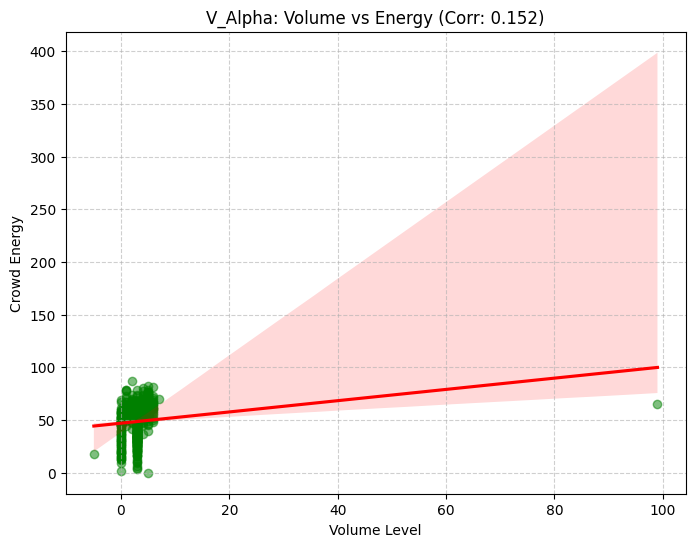

In [126]:
monastery_data = df_clean[df_clean['Venue_ID'] == 'V_Alpha']
corr_monastery = monastery_data['Volume_Level'].corr(monastery_data['Crowd_Energy'])

print(f"Correlation (V_Alpha): {corr_monastery}")

plt.figure(figsize=(8, 6))
sns.regplot(data=monastery_data, x='Volume_Level', y='Crowd_Energy',
            scatter_kws={'alpha':0.5, 'color':'green'},
            line_kws={'color':'red'})
plt.title(f'V_Alpha: Volume vs Energy (Corr: {corr_monastery:.3f})')
plt.xlabel('Volume Level')
plt.ylabel('Crowd Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Conclusion:The Singer is wrong, the monastery actually prefers loud music**

**Verifying Hypothesis: Goths only come alive at night**

Average Crowd Energy (Day vs Night):
Time_of_Day        Day      Night
Venue_ID                         
V_Alpha      45.854576  49.456972
V_Beta        5.946827  54.485466
V_Delta      58.712353  55.084597
V_Gamma      69.853810  68.066435


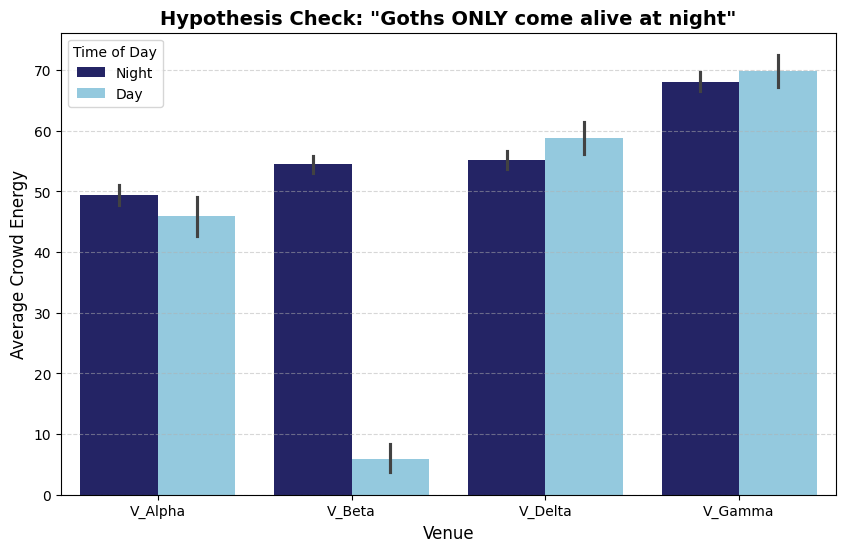

In [127]:
df_clean['Hour'] = pd.to_datetime(df_clean['Time'], format='%H:%M:%S').dt.hour
df_clean['Time_of_Day'] = df_clean['Hour'].apply(lambda h: 'Night' if h >= 18 else 'Day')

goth_check = df_clean.groupby(['Venue_ID', 'Time_of_Day'])['Crowd_Energy'].mean().unstack()
print("Average Crowd Energy (Day vs Night):")
print(goth_check)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x='Venue_ID',
    y='Crowd_Energy',
    hue='Time_of_Day',
    palette={'Day': 'skyblue', 'Night': 'midnightblue'}
)

plt.title('Hypothesis Check: "Goths ONLY come alive at night"', fontsize=14, fontweight='bold')
plt.xlabel("Venue", fontsize=12)
plt.ylabel("Average Crowd Energy", fontsize=12)
plt.legend(title='Time of Day')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Conclusion: The Hypothesis is Completely True, but the singer claiming night shows are better at all venues is not true**

**Verifying Moon Cycle Corellation**

Average Crowd Energy by Moon Phase:
Moon_Phase
Waxing Gibbous     56.067818
Last Quarter       54.404978
Waxing Crescent    54.281953
Full Moon          54.225464
Waning Gibbous     54.084797
New Moon           53.865000
First Quarter      53.860615
Waning Crescent    53.213068
Name: Crowd_Energy, dtype: float64


/tmp/ipython-input-3680040819.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


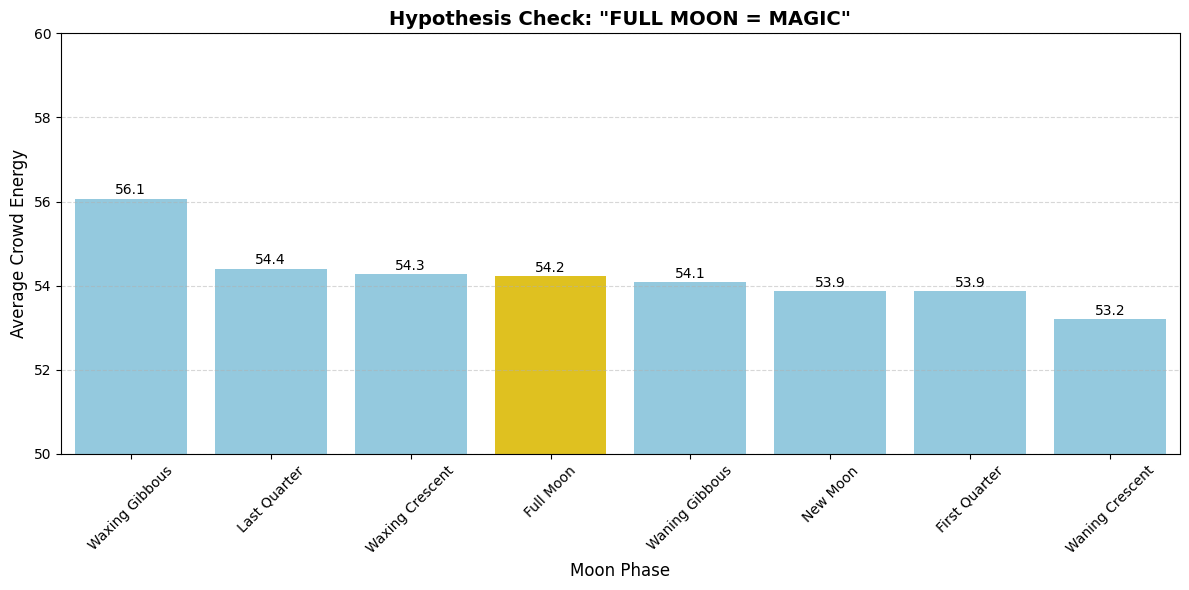

In [128]:
moon_stats = df_clean.groupby('Moon_Phase')['Crowd_Energy'].mean().sort_values(ascending=False)
print("Average Crowd Energy by Moon Phase:")
print(moon_stats)

plt.figure(figsize=(12, 6))

colors = ['gold' if x == 'Full Moon' else 'skyblue' for x in moon_stats.index]

sns.barplot(
    x=moon_stats.index,
    y=moon_stats.values,
    palette=colors
)

plt.title('Hypothesis Check: "FULL MOON = MAGIC"', fontsize=14, fontweight='bold')
plt.xlabel("Moon Phase", fontsize=12)
plt.ylabel("Average Crowd Energy", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(50, 60)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for i, v in enumerate(moon_stats.values):
    plt.text(i, v + 0.1, f"{v:.1f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Conclusion:The singer is completely wrong about this**

**Verifying Outfit Preferences by Venue**

Average Crowd Energy by Venue and Outfit:
Band_Outfit      Denim    Leather    Spandex
Venue_ID                                    
V_Alpha      48.255470  49.285760  48.041627
V_Beta       43.213197  35.821920  40.078387
V_Delta      54.636357  55.742108  59.012072
V_Gamma      67.390000  69.440052  68.767982


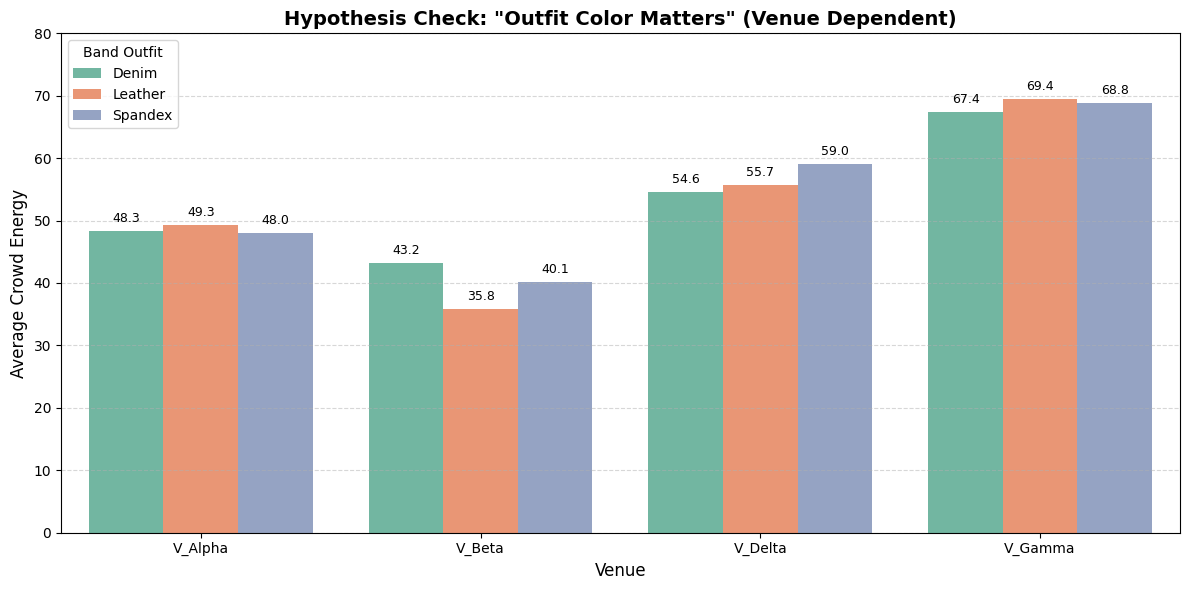

In [129]:
outfit_stats = df_clean.groupby(['Venue_ID', 'Band_Outfit'])['Crowd_Energy'].mean().unstack()
print("Average Crowd Energy by Venue and Outfit:")
print(outfit_stats)

plt.figure(figsize=(12, 6))

df_outfit = df_clean.groupby(['Venue_ID', 'Band_Outfit'])['Crowd_Energy'].mean().reset_index()

sns.barplot(
    data=df_outfit,
    x='Venue_ID',
    y='Crowd_Energy',
    hue='Band_Outfit',
    palette='Set2'
)

plt.title('Hypothesis Check: "Outfit Color Matters" (Venue Dependent)', fontsize=14, fontweight='bold')
plt.xlabel("Venue", fontsize=12)
plt.ylabel("Average Crowd Energy", fontsize=12)
plt.ylim(0, 80)
plt.legend(title='Band Outfit')
plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

**Conclusion: Outfit does matter, at the vampire's den denim is preferred, at the snob pit Spandex is preferred and at the other two it hardly makes a difference**

/tmp/ipython-input-1671651068.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


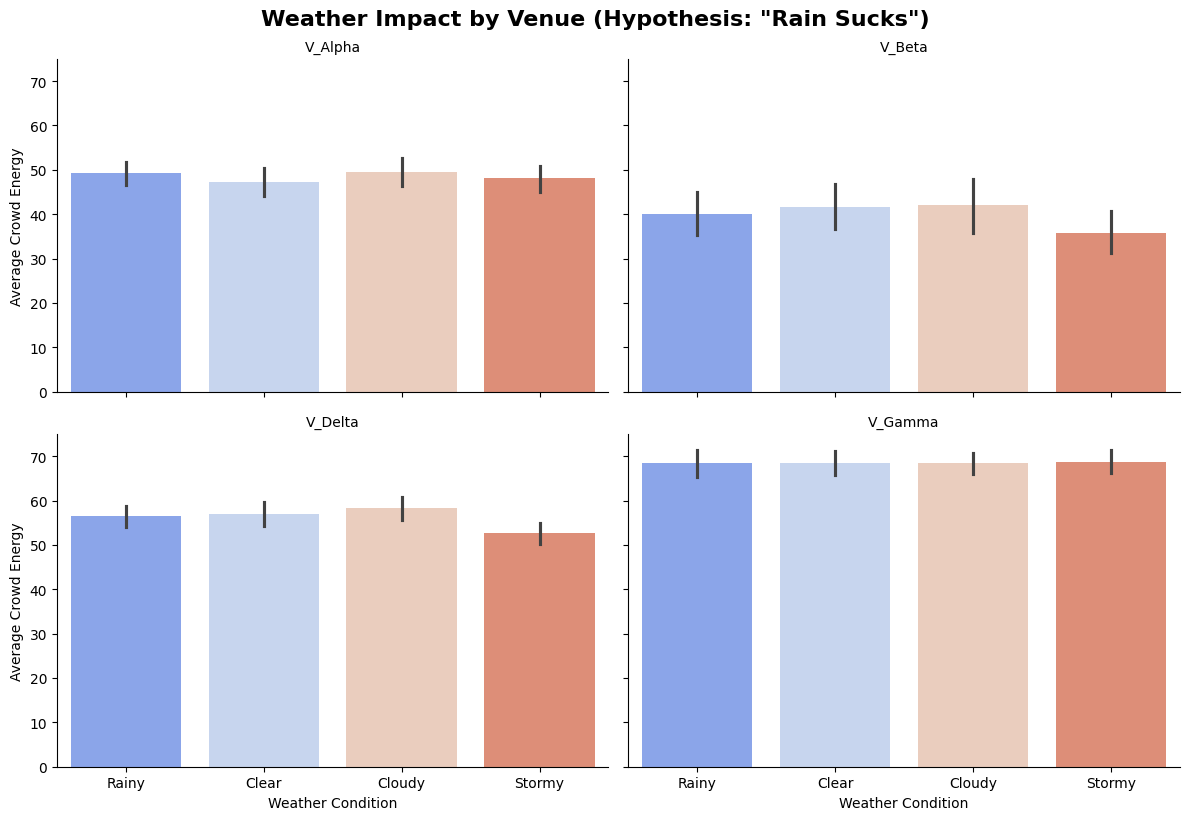

In [130]:
g = sns.catplot(
    data=df_clean,
    x='Weather',
    y='Crowd_Energy',
    col='Venue_ID',
    kind='bar',
    col_wrap=2,
    palette='coolwarm',
    height=4,
    aspect=1.5
)

g.fig.suptitle('Weather Impact by Venue (Hypothesis: "Rain Sucks")', y=1.02, fontsize=16, fontweight='bold')
g.set_axis_labels("Weather Condition", "Average Crowd Energy")
g.set_titles("{col_name}")

plt.show()

**Conclusion: Stormy weather is in general bad for energy, espescially in venue beta and delta. Weather seems to have no effect in venue gamma indicating indoor venue**

**Verifying Price vs Energy**

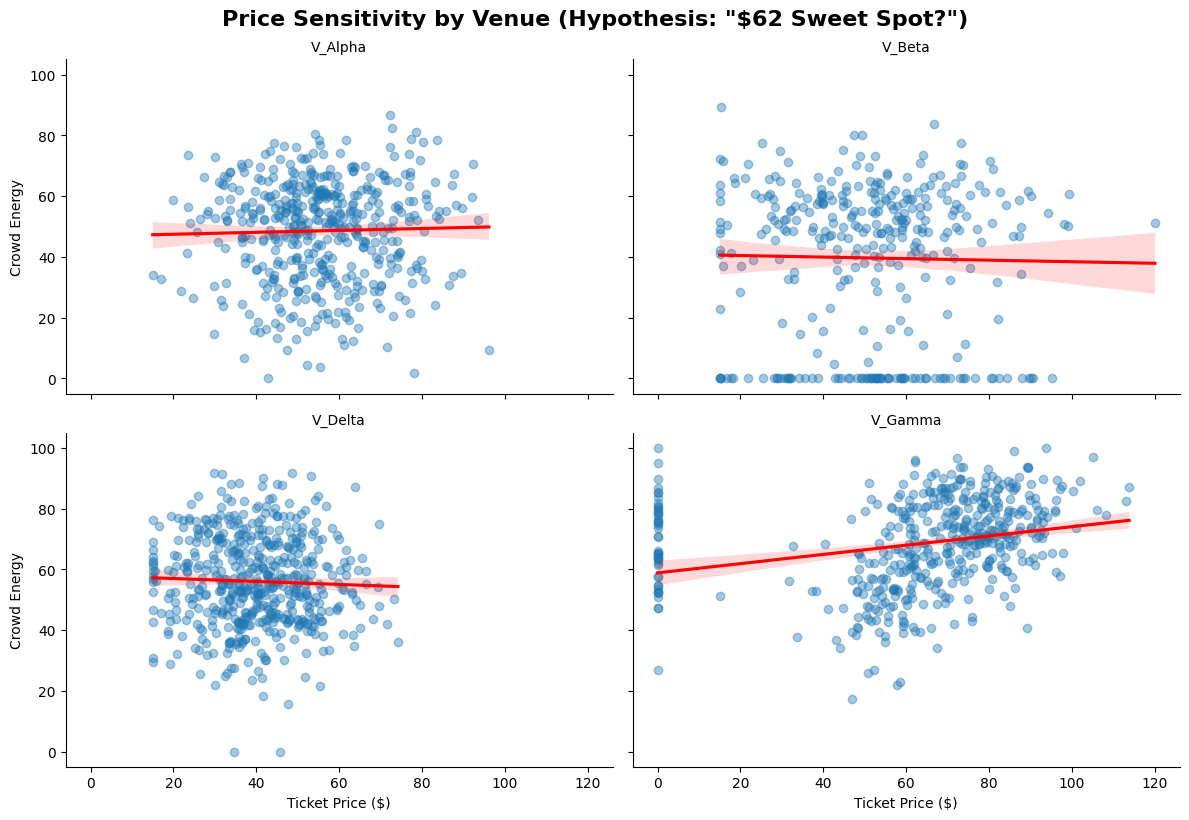

Correlation between Price and Energy (by Venue):
Venue_ID              
V_Alpha   Ticket_Price    0.027667
V_Beta    Ticket_Price   -0.019858
V_Delta   Ticket_Price   -0.039329
V_Gamma   Ticket_Price    0.253652
Name: Crowd_Energy, dtype: float64


In [131]:
g = sns.lmplot(
    data=df_clean,
    x='Ticket_Price',
    y='Crowd_Energy',
    col='Venue_ID',
    col_wrap=2,
    height=4,
    aspect=1.5,
    line_kws={'color': 'red'},
    scatter_kws={'alpha': 0.4}
)

g.fig.suptitle('Price Sensitivity by Venue (Hypothesis: "$62 Sweet Spot?")', y=1.02, fontsize=16, fontweight='bold')
g.set_axis_labels("Ticket Price ($)", "Crowd Energy")
g.set_titles("{col_name}")

plt.show()

print("Correlation between Price and Energy (by Venue):")
print(df_clean.groupby('Venue_ID')[['Ticket_Price', 'Crowd_Energy']].corr().iloc[0::2, -1])

**Conclusion: The singer seems to be correct that prices matter positively in the snob pit, they aren't really relavant in the rest though**

**Verifying crowd size vs energy in the mosh pit**

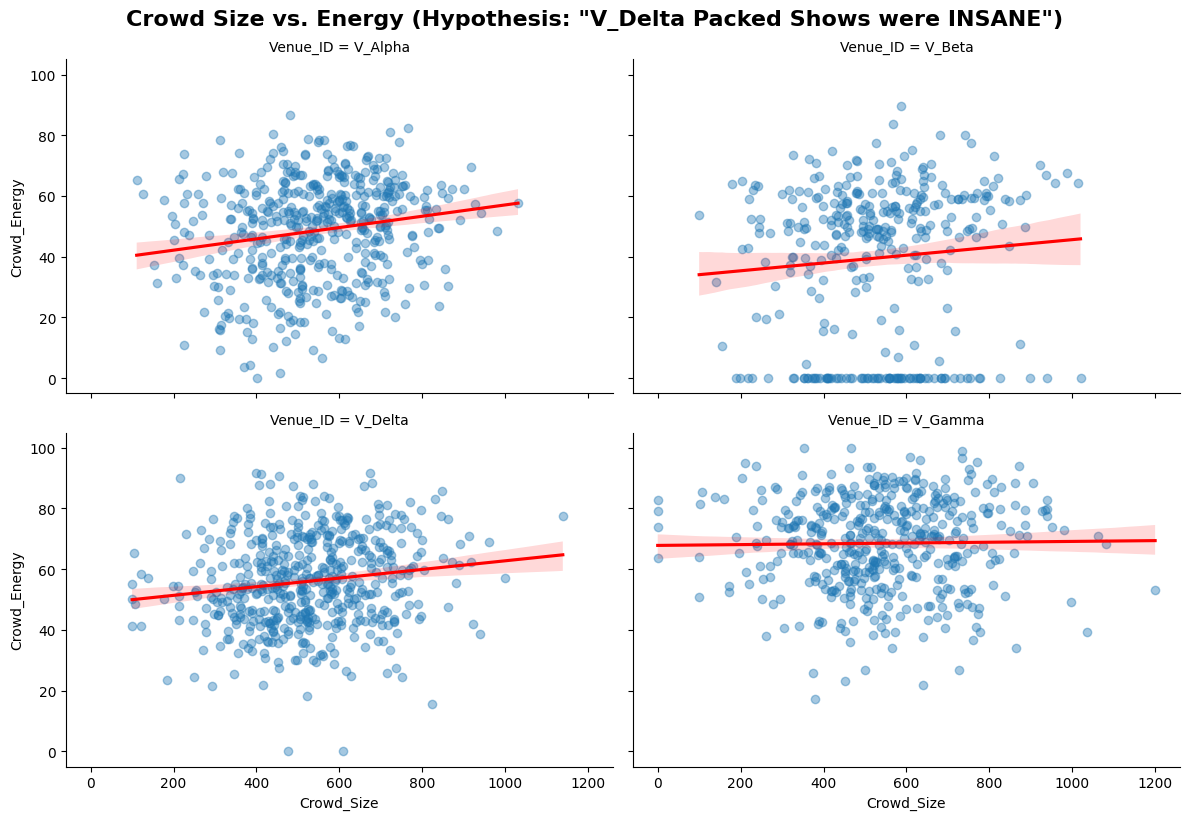

Correlation between Crowd Size and Energy (by Venue):
Venue_ID            
V_Alpha   Crowd_Size    0.178876
V_Beta    Crowd_Size    0.086732
V_Delta   Crowd_Size    0.151625
V_Gamma   Crowd_Size    0.015874
Name: Crowd_Energy, dtype: float64


In [132]:
g = sns.lmplot(
    data=df_clean,
    x='Crowd_Size',
    y='Crowd_Energy',
    col='Venue_ID',
    col_wrap=2,
    height=4,
    aspect=1.5,
    line_kws={'color': 'red'},
    scatter_kws={'alpha': 0.4}
)

g.fig.suptitle('Crowd Size vs. Energy (Hypothesis: "V_Delta Packed Shows were INSANE")', y=1.02, fontsize=16, fontweight='bold')
plt.show()

print("Correlation between Crowd Size and Energy (by Venue):")
corrs = df_clean.groupby('Venue_ID')[['Crowd_Size', 'Crowd_Energy']].corr().iloc[0::2, -1]
print(corrs)

**Conclusion: The crowd energy clearly increases with increase in crowd size in the mosh pit**

In [133]:
df_clean.to_csv('tour_logs_cleaned_final.csv', index=False)

In [134]:
df_clean

,Gig_ID,Venue_ID,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Weather,Moon_Phase,Band_Outfit,Merch_Sales_Post_Show,Crowd_Energy,Date,Time,Day_Name,Hour,Time_of_Day
0,Gig_0000,V_Alpha,3,5.0,52.93,464.0,2,Rainy,Waning Crescent,Leather,916,64.96,2024-03-07,21:00:00,Thursday,21,Night
1,Gig_0001,V_Beta,3,2.0,66.33,388.0,5,Clear,New Moon,Leather,1003,66.42,2024-09-05,22:00:00,Thursday,22,Night
2,Gig_0002,V_Delta,5,1.0,51.37,679.0,1,Rainy,Waning Crescent,Denim,720,42.58,2024-03-09,15:00:00,Saturday,15,Day
3,Gig_0003,V_Beta,0,10.0,64.77,454.0,1,Rainy,New Moon,Leather,0,0.00,2024-07-08,08:00:00,Monday,8,Day
4,Gig_0004,V_Delta,4,8.0,47.34,654.0,5,Cloudy,Full Moon,Spandex,950,67.55,2024-04-26,17:00:00,Friday,17,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,Gig_1993,V_Beta,0,7.0,55.01,323.0,3,Clear,New Moon,Denim,885,58.87,2024-06-10,23:00:00,Monday,23,Night
1994,Gig_1994,V_Beta,6,4.0,62.86,432.0,4,Cloudy,Waxing Gibbous,Denim,942,61.32,2024-08-18,20:00:00,Sunday,20,Night
1995,Gig_1995,V_Alpha,6,3.0,57.34,699.0,5,Stormy,First Quarter,Denim,601,40.67,2024-06-16,20:00:00,Sunday,20,Night
1996,Gig_1996,V_Beta,3,7.0,26.94,588.0,5,Stormy,Full Moon,Spandex,897,65.60,2024-05-23,23:00:00,Thursday,23,Night
